In [1]:
# =========================
# 1. Установка и импорт библиотек
# =========================

import os
import time
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import seaborn as sns

print("TensorFlow version:", tf.__version__)
print("GPU доступен:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU доступен: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [2]:
# =========================
# 2. Загрузка датасета CIFAR-10
# =========================
# CIFAR-10:
# 10 классов
# RGB изображения
# размер изображений 32x32
# отлично подходит под условия практической работы

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

# Преобразуем метки из формы (n, 1) в (n,)
y_train = y_train.flatten()
y_test = y_test.flatten()

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

print("Размер обучающей выборки:", x_train.shape, y_train.shape)
print("Размер тестовой выборки:", x_test.shape, y_test.shape)
print("Количество классов:", len(class_names))

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
Размер обучающей выборки: (50000, 32, 32, 3) (50000,)
Размер тестовой выборки: (10000, 32, 32, 3) (10000,)
Количество классов: 10


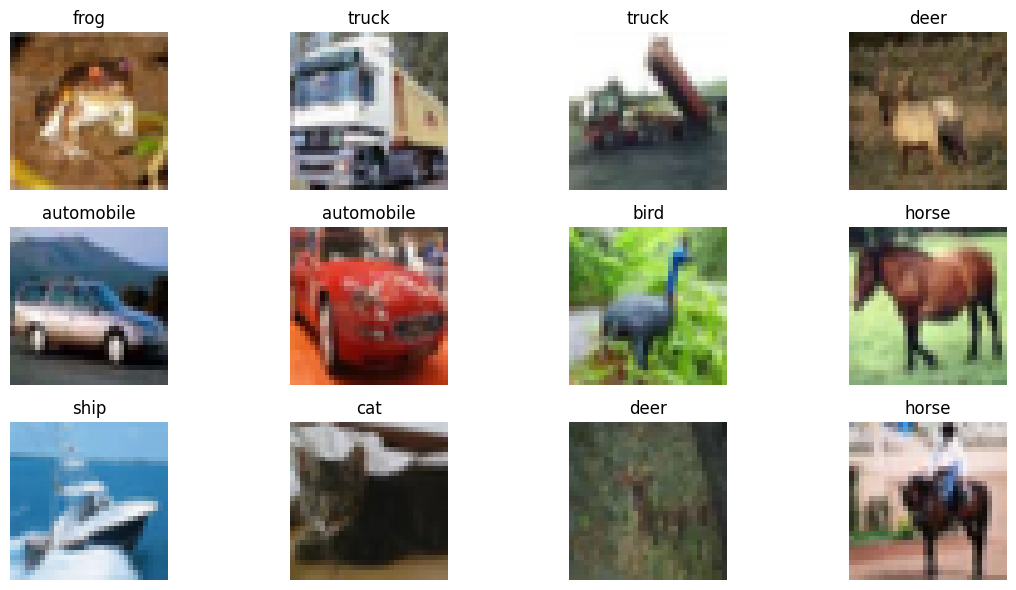

In [3]:
# =========================
# 3. Посмотрим на несколько изображений
# =========================

plt.figure(figsize=(12, 6))
for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [4]:
# =========================
# 4. Нормализация данных
# =========================
# Приводим значения пикселей к диапазону [0, 1]

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Выделим часть обучающей выборки под валидацию
val_size = 5000

x_val = x_train[-val_size:]
y_val = y_train[-val_size:]

x_train_small = x_train[:-val_size]
y_train_small = y_train[:-val_size]

print("Train:", x_train_small.shape, y_train_small.shape)
print("Val:", x_val.shape, y_val.shape)
print("Test:", x_test.shape, y_test.shape)

Train: (45000, 32, 32, 3) (45000,)
Val: (5000, 32, 32, 3) (5000,)
Test: (10000, 32, 32, 3) (10000,)


In [5]:
# =========================
# 5. Аугментация данных
# =========================
# Нужна, чтобы модель лучше обобщала данные

data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
], name="data_augmentation")

In [6]:
# =========================
# 6. Функция построения модели
# =========================
# Мы будем создавать 2 модели:
# 1) baseline_model - базовая
# 2) fast_model - более легкая и быстрая

def build_cnn_model(
    input_shape=(32, 32, 3),
    num_classes=10,
    conv_filters=(32, 64, 128),
    dense_units=128,
    activation="relu",
    use_batchnorm=False,
    dropout_rate=0.3,
    name="cnn_model"
):
    inputs = keras.Input(shape=input_shape)

    x = data_augmentation(inputs)

    # Блок 1
    x = layers.Conv2D(conv_filters[0], (3, 3), padding="same")(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Блок 2
    x = layers.Conv2D(conv_filters[1], (3, 3), padding="same")(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Блок 3
    x = layers.Conv2D(conv_filters[2], (3, 3), padding="same")(x)
    if use_batchnorm:
        x = layers.BatchNormalization()(x)
    x = layers.Activation(activation)(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Вместо Flatten используем GlobalAveragePooling2D
    # Это уменьшает число параметров и часто ускоряет модель
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(dense_units, activation=activation)(x)
    x = layers.Dropout(dropout_rate)(x)

    # Для многоклассовой классификации используем Softmax
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=name)
    return model

In [7]:
# =========================
# 7. Создаем модели
# =========================

# Базовая модель: чуть тяжелее, но обычно точнее
baseline_model = build_cnn_model(
    conv_filters=(32, 64, 128),
    dense_units=128,
    activation="relu",
    use_batchnorm=True,
    dropout_rate=0.3,
    name="baseline_model"
)

# Быстрая модель: меньше фильтров и меньший dense-слой
fast_model = build_cnn_model(
    conv_filters=(16, 32, 64),
    dense_units=64,
    activation="relu",
    use_batchnorm=False,
    dropout_rate=0.2,
    name="fast_model"
)

baseline_model.summary()
print("\n" + "="*70 + "\n")
fast_model.summary()

Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 111,946 (437.29 KB)

 Trainable params: 111,498 (435.54 KB)

 Non-trainable params: 448 (1.75 KB)

Model: "fast_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,394 (110.91 KB)

 Trainable params: 28,394 (110.91 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
# =========================
# 8. Компиляция моделей
# =========================

def compile_model(model):
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )

compile_model(baseline_model)
compile_model(fast_model)

In [9]:
# =========================
# 9. Колбэки
# =========================
# EarlyStopping - чтобы обучение не тянулось зря
# ReduceLROnPlateau - чтобы уменьшать learning rate, если модель "застряла"

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-6
    )
]

In [10]:
# =========================
# 10. Обучение baseline-модели
# =========================

EPOCHS = 20
BATCH_SIZE = 128

start_time = time.time()

history_baseline = baseline_model.fit(
    x_train_small, y_train_small,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

baseline_train_time = time.time() - start_time
print(f"Время обучения baseline_model: {baseline_train_time:.2f} сек")

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - accuracy: 0.3360 - loss: 1.7654 - val_accuracy: 0.1912 - val_loss: 2.7482 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4519 - loss: 1.4903 - val_accuracy: 0.4462 - val_loss: 1.4630 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.5000 - loss: 1.3712 - val_accuracy: 0.4188 - val_loss: 2.0242 - learning_rate: 0.0010
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5283 - loss: 1.3010 - val_accuracy: 0.3040 - val_loss: 2.5408 - learning_rate: 0.0010
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5602 - loss: 1.2214 - val_accuracy: 0.5892 - val_loss: 1.1824 - learning_rate: 5.0000e-04
Epoch 6/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5727 - loss: 1.1851 - val_accuracy: 0.6022 - val_loss: 1.1601 - learning_rate: 5.0000e-04
Epoch 7/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - accuracy: 0.5838 

In [11]:
# =========================
# 11. Обучение fast-модели
# =========================

start_time = time.time()

history_fast = fast_model.fit(
    x_train_small, y_train_small,
    validation_data=(x_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

fast_train_time = time.time() - start_time
print(f"Время обучения fast_model: {fast_train_time:.2f} сек")

Epoch 1/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.2195 - loss: 2.0294 - val_accuracy: 0.2872 - val_loss: 1.8887 - learning_rate: 0.0010
Epoch 2/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3096 - loss: 1.7876 - val_accuracy: 0.3726 - val_loss: 1.6590 - learning_rate: 0.0010
Epoch 3/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.3552 - loss: 1.6949 - val_accuracy: 0.3774 - val_loss: 1.7336 - learning_rate: 5.0000e-04
Epoch 4/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.3758 - loss: 1.6590 - val_accuracy: 0.4030 - val_loss: 1.6407 - learning_rate: 5.0000e-04
Epoch 5/20
352/352 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.3934 - loss: 1.6200 - val_accuracy: 0.4078 - val_loss: 1.6438 - learning_rate: 2.5000e-04
Время обучения fast_model: 21.34 сек


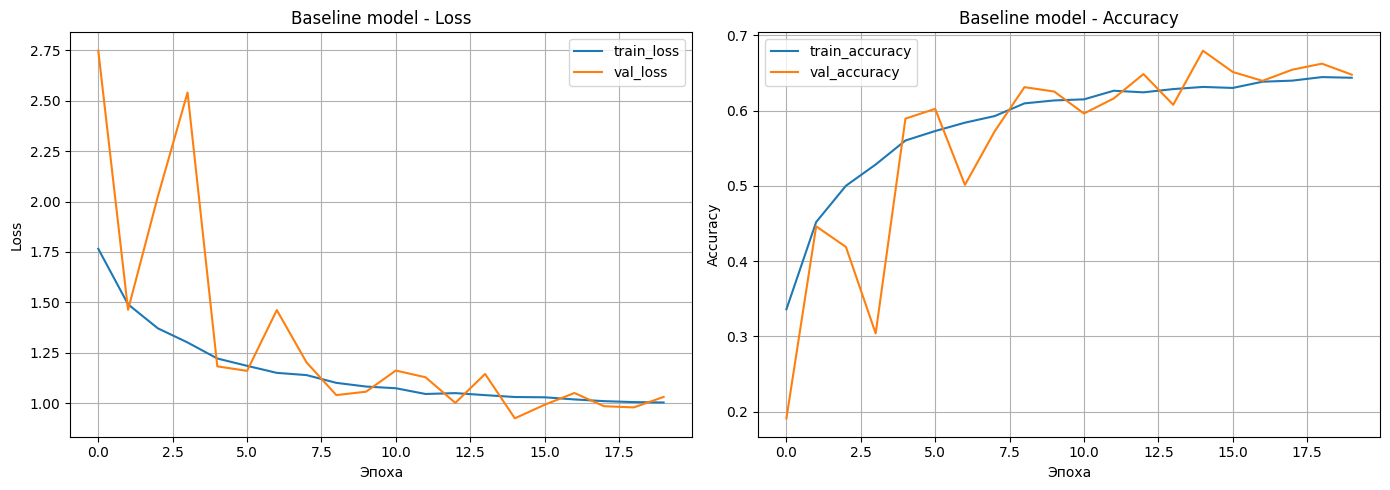

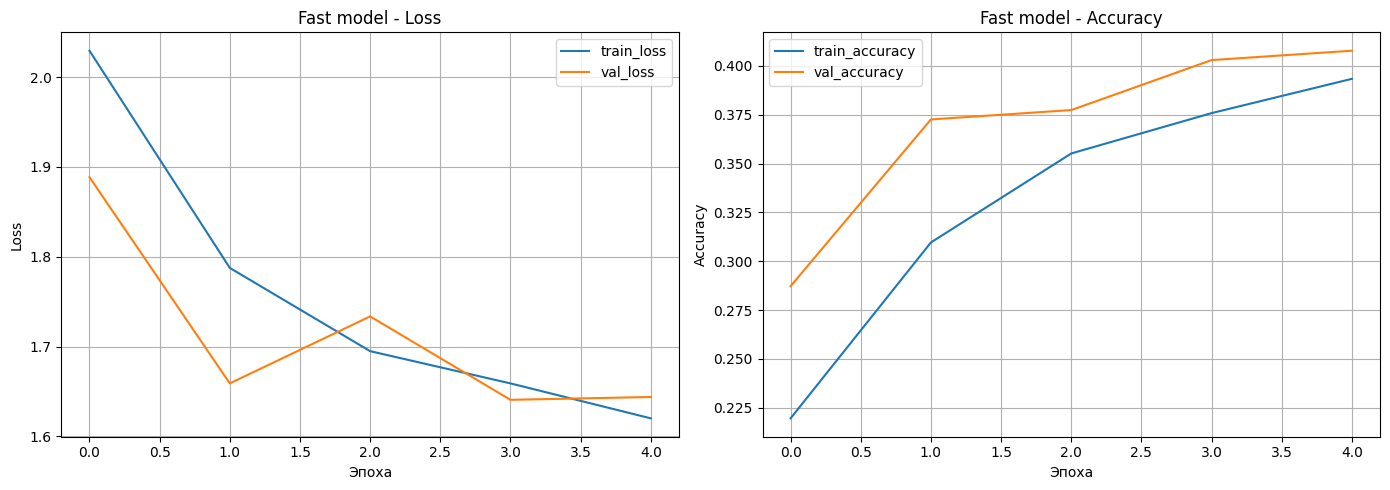

In [12]:
# =========================
# 12. Построение графиков
# =========================

def plot_history(history, title="История обучения"):
    hist = pd.DataFrame(history.history)

    plt.figure(figsize=(14, 5))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(hist["loss"], label="train_loss")
    plt.plot(hist["val_loss"], label="val_loss")
    plt.title(f"{title} - Loss")
    plt.xlabel("Эпоха")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(hist["accuracy"], label="train_accuracy")
    plt.plot(hist["val_accuracy"], label="val_accuracy")
    plt.title(f"{title} - Accuracy")
    plt.xlabel("Эпоха")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()

plot_history(history_baseline, "Baseline model")
plot_history(history_fast, "Fast model")

In [13]:
# =========================
# 13. Функции оценки модели
# =========================

def evaluate_model(model, x_test, y_test, class_names, batch_size=256):
    # Оценка loss и accuracy встроенными средствами Keras
    test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

    # Предсказания
    y_prob = model.predict(x_test, batch_size=batch_size, verbose=0)
    y_pred = np.argmax(y_prob, axis=1)

    # Дополнительные метрики
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average="macro")
    f1_weighted = f1_score(y_test, y_pred, average="weighted")

    print(f"Test loss: {test_loss:.4f}")
    print(f"Test accuracy (keras): {test_acc:.4f}")
    print(f"Accuracy (sklearn): {acc:.4f}")
    print(f"F1 macro: {f1_macro:.4f}")
    print(f"F1 weighted: {f1_weighted:.4f}")

    print("\nClassification report:\n")
    print(classification_report(y_test, y_pred, target_names=class_names))

    return {
        "test_loss": test_loss,
        "test_accuracy": test_acc,
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "y_pred": y_pred
    }

def measure_fps(model, x_data, warmup=100, batch_size=256):
    """
    FPS = сколько изображений модель обрабатывает за секунду.
    Сначала небольшой "разогрев", потом измерение времени.
    """

    # Разогрев GPU/модели
    _ = model.predict(x_data[:warmup], batch_size=batch_size, verbose=0)

    start_time = time.time()
    _ = model.predict(x_data, batch_size=batch_size, verbose=0)
    total_time = time.time() - start_time

    fps = len(x_data) / total_time
    return fps, total_time

In [14]:
# =========================
# 14. Оценка baseline_model
# =========================

baseline_results = evaluate_model(baseline_model, x_test, y_test, class_names)

baseline_fps, baseline_infer_time = measure_fps(baseline_model, x_test)
print(f"\nBaseline FPS: {baseline_fps:.2f} кадров/сек")
print(f"Baseline inference time на {len(x_test)} изображениях: {baseline_infer_time:.4f} сек")

Test loss: 0.9354
Test accuracy (keras): 0.6703
Accuracy (sklearn): 0.6703
F1 macro: 0.6601
F1 weighted: 0.6601

Classification report:

              precision    recall  f1-score   support

    airplane       0.69      0.68      0.69      1000
  automobile       0.79      0.85      0.82      1000
        bird       0.71      0.37      0.48      1000
         cat       0.49      0.37      0.42      1000
        deer       0.67      0.52      0.58      1000
         dog       0.58      0.61      0.60      1000
        frog       0.54      0.87      0.66      1000
       horse       0.75      0.75      0.75      1000
        ship       0.77      0.85      0.81      1000
       truck       0.75      0.83      0.79      1000

    accuracy                           0.67     10000
   macro avg       0.67      0.67      0.66     10000
weighted avg       0.67      0.67      0.66     10000


Baseline FPS: 16907.05 кадров/сек
Baseline inference time на 10000 изображениях: 0.5915 сек


In [15]:
# =========================
# 15. Оценка fast_model
# =========================

fast_results = evaluate_model(fast_model, x_test, y_test, class_names)

fast_fps, fast_infer_time = measure_fps(fast_model, x_test)
print(f"\nFast FPS: {fast_fps:.2f} кадров/сек")
print(f"Fast inference time на {len(x_test)} изображениях: {fast_infer_time:.4f} сек")

Test loss: 1.8926
Test accuracy (keras): 0.2793
Accuracy (sklearn): 0.2793
F1 macro: 0.2455
F1 weighted: 0.2455

Classification report:

              precision    recall  f1-score   support

    airplane       0.44      0.08      0.14      1000
  automobile       0.28      0.62      0.38      1000
        bird       0.31      0.04      0.07      1000
         cat       0.22      0.25      0.23      1000
        deer       0.41      0.20      0.27      1000
         dog       0.42      0.10      0.16      1000
        frog       0.27      0.31      0.29      1000
       horse       0.21      0.21      0.21      1000
        ship       0.32      0.65      0.43      1000
       truck       0.23      0.34      0.28      1000

    accuracy                           0.28     10000
   macro avg       0.31      0.28      0.25     10000
weighted avg       0.31      0.28      0.25     10000


Fast FPS: 6932.67 кадров/сек
Fast inference time на 10000 изображениях: 1.4424 сек


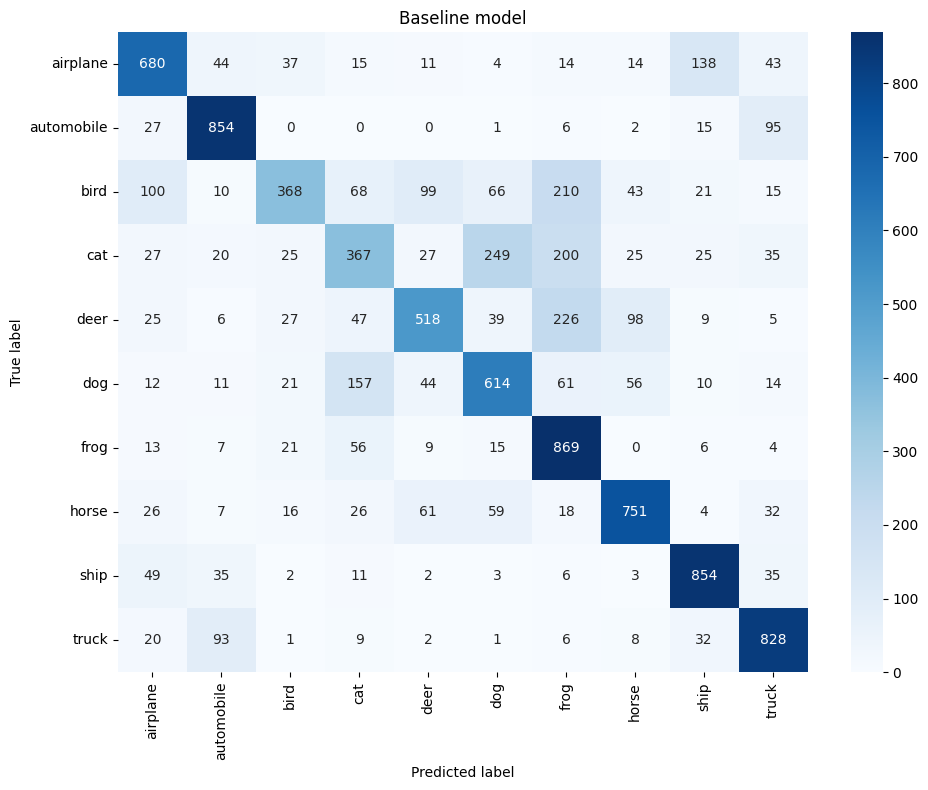

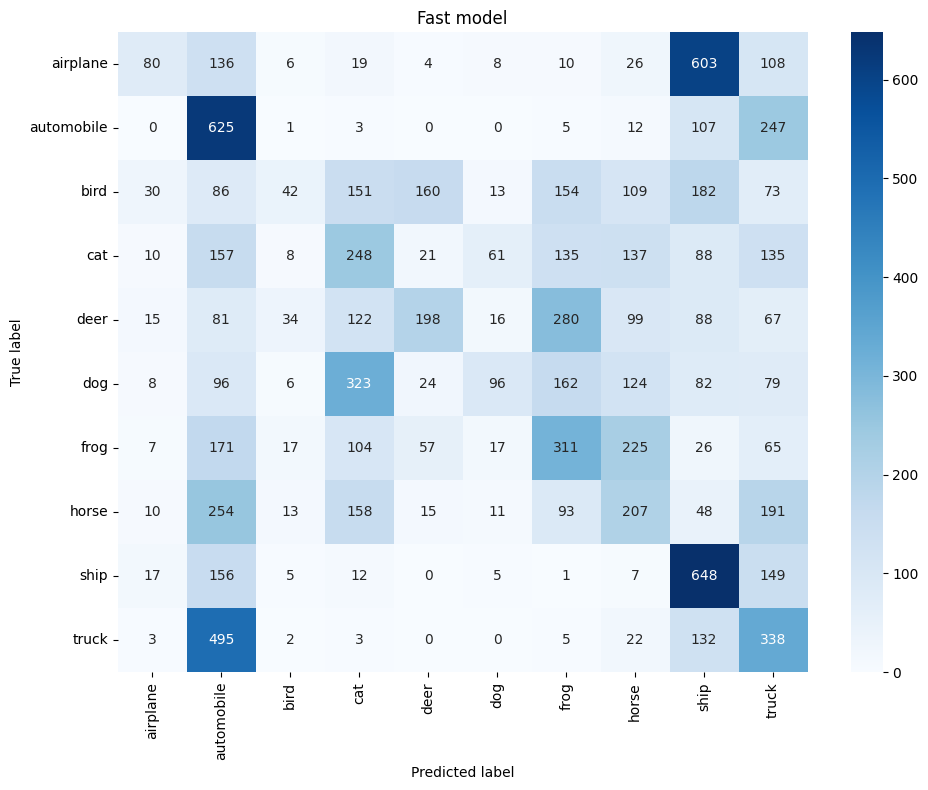

In [16]:
# =========================
# 16. Матрицы ошибок
# =========================

def plot_confusion_matrix(y_true, y_pred, class_names, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title)
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

plot_confusion_matrix(y_test, baseline_results["y_pred"], class_names, "Baseline model")
plot_confusion_matrix(y_test, fast_results["y_pred"], class_names, "Fast model")

In [17]:
# =========================
# 17. Сравнительная таблица
# =========================

comparison_df = pd.DataFrame([
    {
        "model": "baseline_model",
        "params": baseline_model.count_params(),
        "train_time_sec": round(baseline_train_time, 2),
        "test_loss": round(baseline_results["test_loss"], 4),
        "accuracy": round(baseline_results["accuracy"], 4),
        "f1_macro": round(baseline_results["f1_macro"], 4),
        "f1_weighted": round(baseline_results["f1_weighted"], 4),
        "fps": round(baseline_fps, 2),
    },
    {
        "model": "fast_model",
        "params": fast_model.count_params(),
        "train_time_sec": round(fast_train_time, 2),
        "test_loss": round(fast_results["test_loss"], 4),
        "accuracy": round(fast_results["accuracy"], 4),
        "f1_macro": round(fast_results["f1_macro"], 4),
        "f1_weighted": round(fast_results["f1_weighted"], 4),
        "fps": round(fast_fps, 2),
    }
])

comparison_df

,model,params,train_time_sec,test_loss,accuracy,f1_macro,f1_weighted,fps
0,baseline_model,111946,140.54,0.9354,0.6703,0.6601,0.6601,16907.05
1,fast_model,28394,21.34,1.8926,0.2793,0.2455,0.2455,6932.67


In [18]:
# =========================
# 18. Сохранение результатов
# =========================

os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

comparison_df.to_csv("results/model_comparison.csv", index=False)

with open("results/baseline_history.json", "w") as f:
    json.dump(history_baseline.history, f)

with open("results/fast_history.json", "w") as f:
    json.dump(history_fast.history, f)

baseline_model.save("models/baseline_model.keras")
fast_model.save("models/fast_model.keras")

print("Результаты и модели сохранены.")

Результаты и модели сохранены.


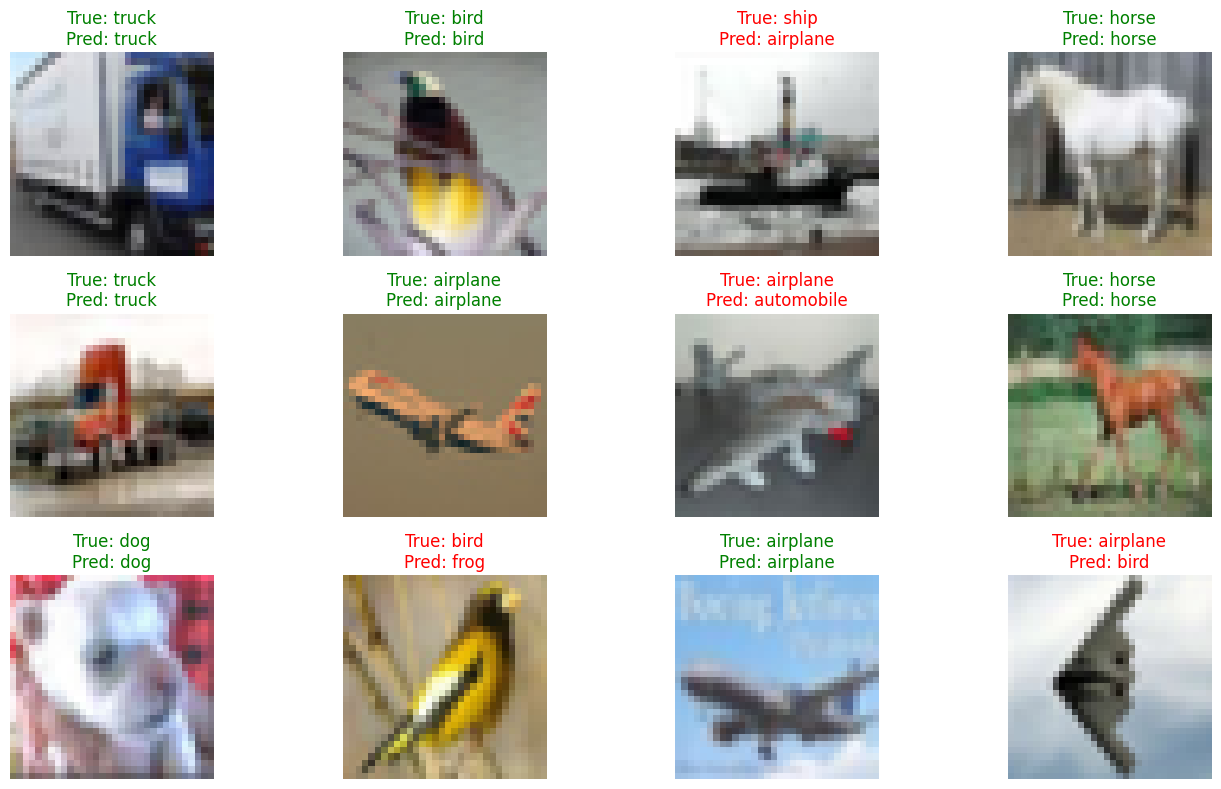

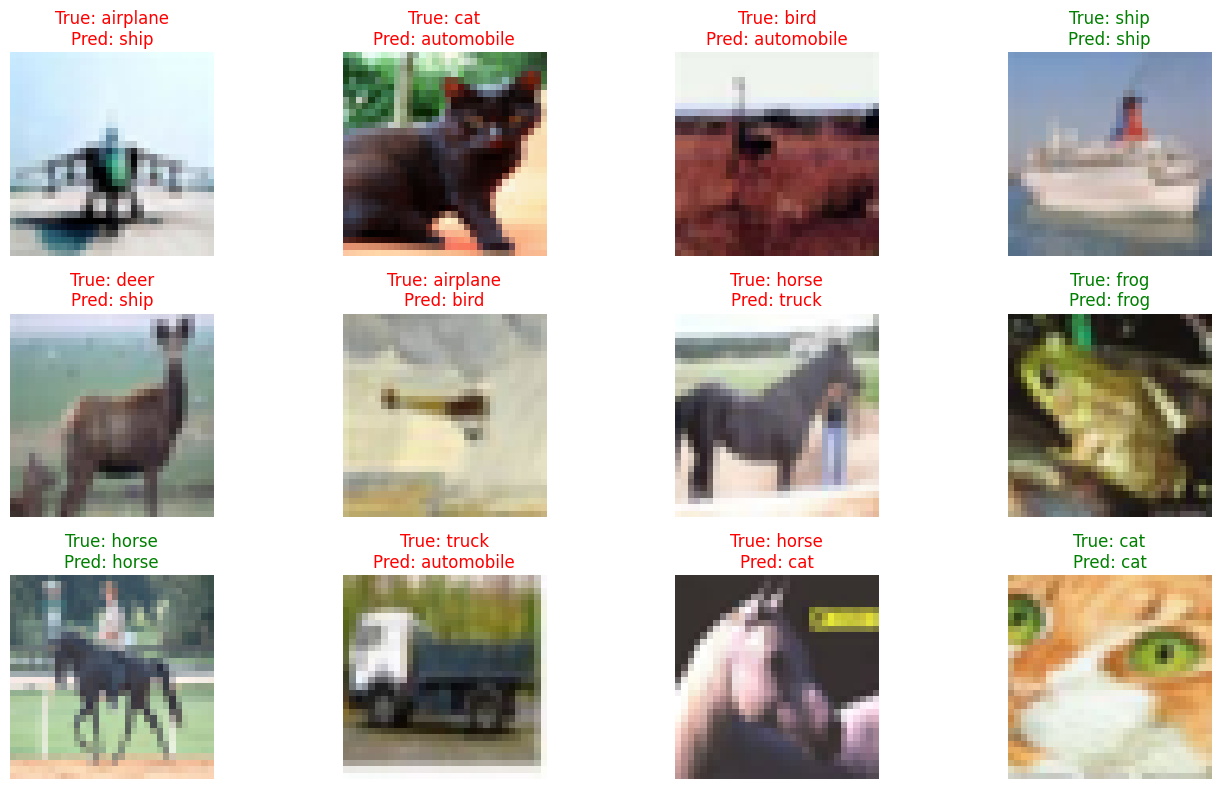

In [19]:
# =========================
# 19. Визуализация предсказаний модели
# =========================

def show_predictions(model, x_data, y_data, class_names, n=12):
    indices = np.random.choice(len(x_data), size=n, replace=False)
    images = x_data[indices]
    true_labels = y_data[indices]

    probs = model.predict(images, verbose=0)
    pred_labels = np.argmax(probs, axis=1)

    plt.figure(figsize=(14, 8))
    for i in range(n):
        plt.subplot(3, 4, i + 1)
        plt.imshow(images[i])
        color = "green" if pred_labels[i] == true_labels[i] else "red"
        plt.title(
            f"True: {class_names[true_labels[i]]}\nPred: {class_names[pred_labels[i]]}",
            color=color
        )
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predictions(baseline_model, x_test, y_test, class_names)
show_predictions(fast_model, x_test, y_test, class_names)

In [20]:
# =========================
# 20. Текстовые выводы для отчета
# =========================

best_model_name = comparison_df.sort_values(by="accuracy", ascending=False).iloc[0]["model"]
fastest_model_name = comparison_df.sort_values(by="fps", ascending=False).iloc[0]["model"]

print("ИТОГОВЫЕ ВЫВОДЫ:")
print()
print("1. Для решения задачи был выбран датасет CIFAR-10, содержащий 10 классов цветных RGB-изображений.")
print("2. Были реализованы две собственные сверточные нейронные сети для многоклассовой классификации.")
print("3. В качестве функции потерь использовалась sparse_categorical_crossentropy,")
print("   так как задача является многоклассовой классификацией.")
print("4. Для оценки качества использовались метрики accuracy, F1-macro и F1-weighted.")
print(f"5. Наилучшее качество показала модель: {best_model_name}.")
print(f"6. Наибольшую скорость обработки изображений показала модель: {fastest_model_name}.")
print("7. Эксперимент с уменьшением числа слоев/фильтров позволил ускорить модель,")
print("   но обычно это сопровождается некоторой потерей точности.")
print("8. Итоговый выбор модели зависит от приоритета:")
print("   - если важнее точность, лучше брать baseline_model;")
print("   - если важнее скорость, лучше брать fast_model.")

ИТОГОВЫЕ ВЫВОДЫ:

1. Для решения задачи был выбран датасет CIFAR-10, содержащий 10 классов цветных RGB-изображений.
2. Были реализованы две собственные сверточные нейронные сети для многоклассовой классификации.
3. В качестве функции потерь использовалась sparse_categorical_crossentropy,
   так как задача является многоклассовой классификацией.
4. Для оценки качества использовались метрики accuracy, F1-macro и F1-weighted.
5. Наилучшее качество показала модель: baseline_model.
6. Наибольшую скорость обработки изображений показала модель: baseline_model.
7. Эксперимент с уменьшением числа слоев/фильтров позволил ускорить модель,
   но обычно это сопровождается некоторой потерей точности.
8. Итоговый выбор модели зависит от приоритета:
   - если важнее точность, лучше брать baseline_model;
   - если важнее скорость, лучше брать fast_model.
